<a href="https://colab.research.google.com/github/zomweno/langchain/blob/master/Unsupervised_Learning_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Assignment — Unsupervised Learning on the Wine Dataset

You're handed the chemical analysis of 178 wines — **13 features each** (alcohol, flavanoids, color
intensity, …) and **no labels**. Your job: use unsupervised learning to discover whether the wines
fall into natural groups, and how many.

> The data *does* secretly come from **3 grape varieties**. You will **only** use those true labels
> at the very end, to score how well your unsupervised pipeline recovered them. Never feed them to
> a model.

### What to do
Fill in every cell marked **`# TODO`**. There are **5 tasks** (Task 5 is a bonus). Each task says
exactly what to produce. A self-check at the bottom verifies your answers.

### What to submit
This notebook with all cells run, plus a 2–3 sentence answer to the **final reflection** question.

---

## 0 · Setup  *(given — just run it)*

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

RNG = 42
wine = load_wine()
X_raw, y_true = wine.data, wine.target     # y_true: ONLY for the final score
print("Data shape:", X_raw.shape, "| features:", len(wine.feature_names), "| true groups:", len(set(y_true)))

Data shape: (178, 13) | features: 13 | true groups: 3


## 🎯 Task 1 — Scale the features
Distance- and variance-based methods need features on a common footing.
**TODO:** create `X` = the standardized version of `X_raw` using `StandardScaler`.

In [12]:
# TODO: standardize X_raw -> X  (mean 0, variance 1 per feature)
X = StandardScaler().fit_transform(X_raw)   # replace with StandardScaler().fit_transform(...)

assert X.shape == X_raw.shape
print("Per-feature mean ~0?", np.allclose(X.mean(0), 0, atol=1e-6),
      "| std ~1?", np.allclose(X.std(0), 1, atol=1e-6))

Per-feature mean ~0? True | std ~1? True


## 🎯 Task 2 — How many PCA components for 90% variance?
**TODO:**
1. Fit `PCA()` on `X`.
2. Compute the **cumulative explained variance**.
3. Set `k90` = the smallest number of components reaching **≥ 90%**.
4. Plot the cumulative curve with a line at 0.90.

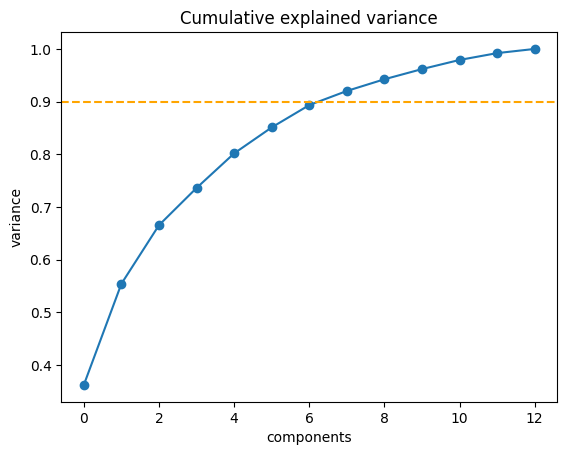

8 components capture >= 90% of the variance


In [13]:
# TODO
pca_full = PCA().fit(X)                                # PCA().fit(X)
cum = np.cumsum(pca_full.explained_variance_ratio_)                             # np.cumsum(pca_full.explained_variance_ratio_)
k90 = int(np.argmax(cum >= 0.90) + 1)                                        # int(np.argmax(cum >= 0.90) + 1)

plt.plot(cum, marker="o")
plt.axhline(0.90, ls="--", color="orange")
plt.title("Cumulative explained variance"); plt.xlabel("components"); plt.ylabel("variance")
plt.show()
print(f"{k90} components capture >= 90% of the variance")

## 🎯 Task 3 — Choose *k* with the silhouette score
**TODO:** for `k` in **2…6**, fit `KMeans` (use `n_init=10, random_state=RNG`) and record the
`silhouette_score`. Pick `best_k` = the `k` with the highest score, then fit the final model
`km` and store its labels in `clusters`.

In [17]:
scores = {}
for k in range(2, 7):
    # TODO: fit KMeans with k clusters on X, compute silhouette_score, store in scores[k]
    km_k = KMeans(n_clusters=k, n_init = 10, random_state=RNG)
    labels_k = km_k.fit_predict(X)
    scores[k] = silhouette_score(X, labels_k)

best_k = max(scores, key=scores.get)
print("Silhouette by k:", {k: round(v, 3) for k, v in scores.items()})
print("Best k =", best_k)

# TODO: fit final KMeans 'km' with best_k and get 'clusters'
km = KMeans(n_clusters=best_k, n_init = 10, random_state=RNG)
clusters = km.fit_predict(X)

Silhouette by k: {2: np.float64(0.259), 3: np.float64(0.285), 4: np.float64(0.26), 5: np.float64(0.202), 6: np.float64(0.237)}
Best k = 3


## 🎯 Task 4 — Score against the truth (Adjusted Rand Index)
Now — and only now — bring in `y_true`. The **Adjusted Rand Index** compares two labelings
(1.0 = identical grouping, ~0 = random).
**TODO:** compute `ari = adjusted_rand_score(y_true, clusters)` and print it.

In [18]:
# TODO
ari = adjusted_rand_score(y_true, clusters)
print(f"Adjusted Rand Index: {ari:.3f}")
print("Did your unsupervised clusters recover the 3 grape varieties?")

Adjusted Rand Index: 0.897
Did your unsupervised clusters recover the 3 grape varieties?


## ⭐ Task 5 — Visualize in 2-D
**TODO:** project `X` to 2 components with PCA and make **two** scatter plots side by side:
left colored by **your `clusters`**, right colored by **`y_true`**. How similar are they?

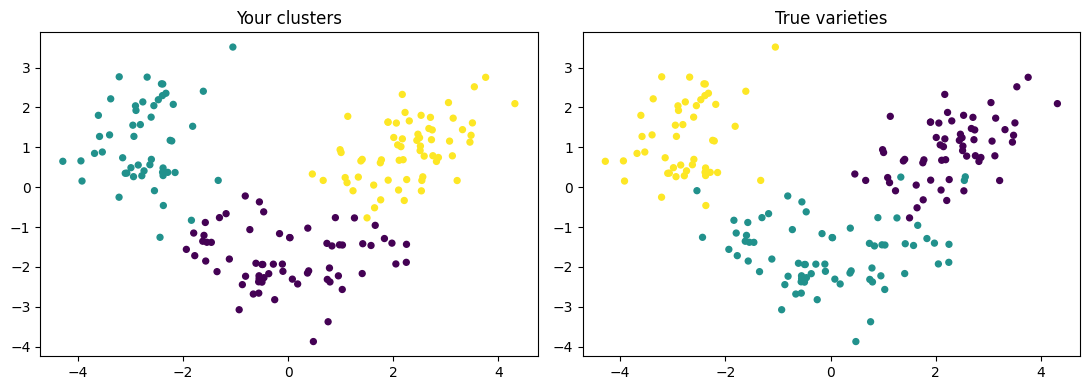

In [19]:
# TODO: X2 = PCA(n_components=2).fit_transform(X)
X2 =PCA(n_components=2).fit_transform(X)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(X2[:, 0], X2[:, 1], c=clusters, cmap="viridis", s=18); ax[0].set_title("Your clusters")
ax[1].scatter(X2[:, 0], X2[:, 1], c=y_true,   cmap="viridis", s=18); ax[1].set_title("True varieties")
plt.tight_layout(); plt.show()

## 🧠 Final reflection *(write your answer here)*

Double-click this cell and answer in 2–3 sentences:

> **You never gave the model the grape labels, yet it found structure.**
> (a) Why did **scaling** matter so much for the ARI?
> (b) In a *real* project with no `y_true` to check against, what **two** pieces of evidence would
> convince you the clusters are real and useful?

**Your answer:**

a) Scaling mattered because the 13 wine features span very different numerical ranges. Without StandardScaler, KMeans distance calcualtions would be almost entirely be controlled by large-scale features, drowning out the finer chemical signals that actually distinguish grape varieties; aftect scaling all 13 features compete on equal footing and their true variety structure can emerge.

b) Two pieces of evidence in a real project with no ground truth are internal validation metrics across multiple k's such as the silhouette score; and domain interpretability. For silhouette score, our k=3 gave the highest score (0.285) across all tested values of k, and it is consistently higher than k = 2 or k = 4, suggesting three is teh natural number of groups. For domain interpretability, inspecting each cluster's average chemical profile to confirm that the groupings make practical sense (for example one cluster having consistently higher alcohol and flavanoid content, which a winemaker would recognise as a coherent grape-variety signature).
